# RL Examples for Lecture 7

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()
from basic_material import R2D

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Phase Calculations with Complex Poles

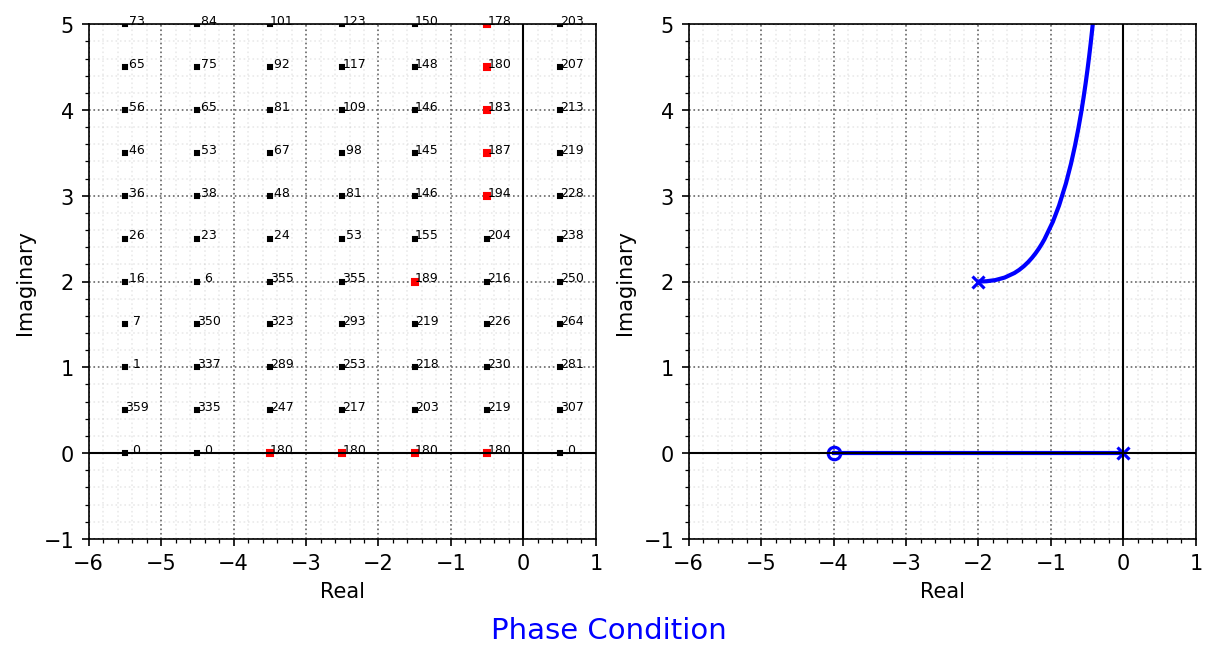

In [4]:
G = ct.tf((1, 4), np.convolve((1,4,8),(1, 0)))

Npts = 7
re = np.linspace(-5.5, .5, Npts)
im = np.linspace(0, 5, Npts+4)

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
for jj,re_s in enumerate(re):
    for ii,im_s in enumerate(im):
        res = cm.phase_at_freq(G,complex(re_s,im_s))
        if abs(res - 180) < 15:
            ax[0].plot(re_s,im_s,'rs',ms=3)
        else:
            ax[0].plot(re_s,im_s,'ks',ms=2)           
        ax[0].text(re_s,im_s,r"{:3.0f}".format(np.round(res,0)),size=6)

rl = ct.rlocus(G,ax=ax[1],color='b')
ax[0].set_ylim((-1,5))
ax[0].set_xlim((-6,1))
ax[1].set_ylim((-1,5))
ax[1].set_xlim((-6,1))
bm.nicegrid(ax,-1)

bm.caption("Phase Condition",fig)
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
plt.savefig("./figs/Phase_cond.pdf", dpi=600)
plt.show()

## Real Line

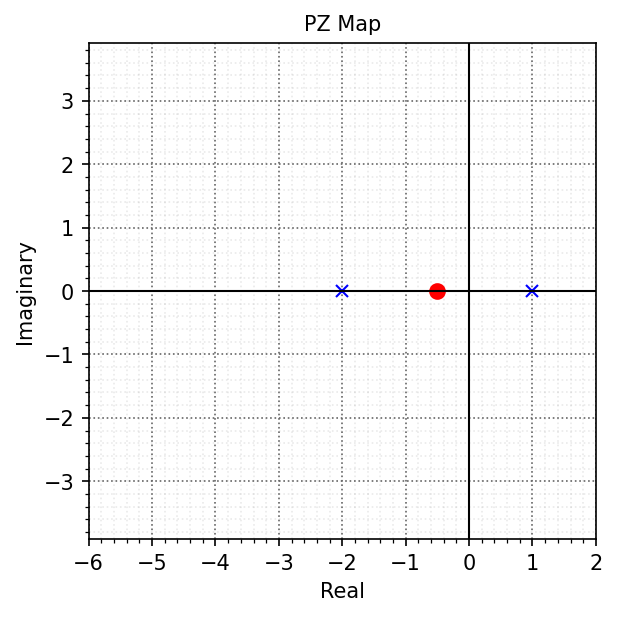

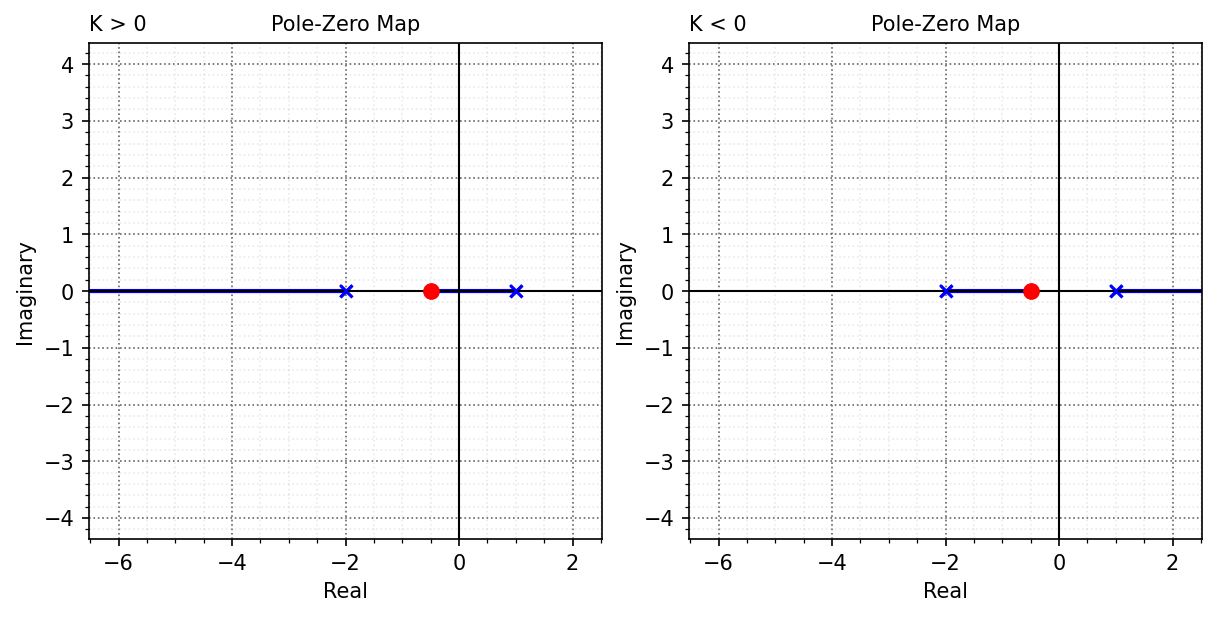

In [5]:
G = ct.tf((1, 0.5), (1, 1, -2))
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150,constrained_layout = True)
cm.new_pzmap(G,ax)
ax.axis('equal')
ax.set_xlim([-6, 2]);ax.set_ylim([-1, 1])
bm.nicegrid(ax,-1)
ax.set_title('PZ Map')
plt.savefig("./figs/RL_ex1_pzmap.pdf", dpi=600)
plt.show()

klist = cm.Root_Locus_gains(G)
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=klist,ax=ax[0],color='b')
ax[0].axis('equal')
ax[0].set_xlim([-6, 2]);ax[0].set_ylim([-1, 1])
bm.nicegrid(ax[0],-1)
ax[0].set_title('K > 0',loc='left')
cm.new_pzmap(G,ax[0])

klist = cm.Root_Locus_gains(G)
rl = ct.rlocus(G, gains=[-kk for kk in klist],ax=ax[1],color='b')
ax[1].axis('equal')
ax[1].set_xlim([-6, 2]);ax[1].set_ylim([-1, 1])
bm.nicegrid(ax[1],-1)
ax[1].set_title('K < 0',loc='left')
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
cm.new_pzmap(G,ax[1])
plt.savefig("./figs/RL_ex1.pdf", dpi=600)
plt.show()

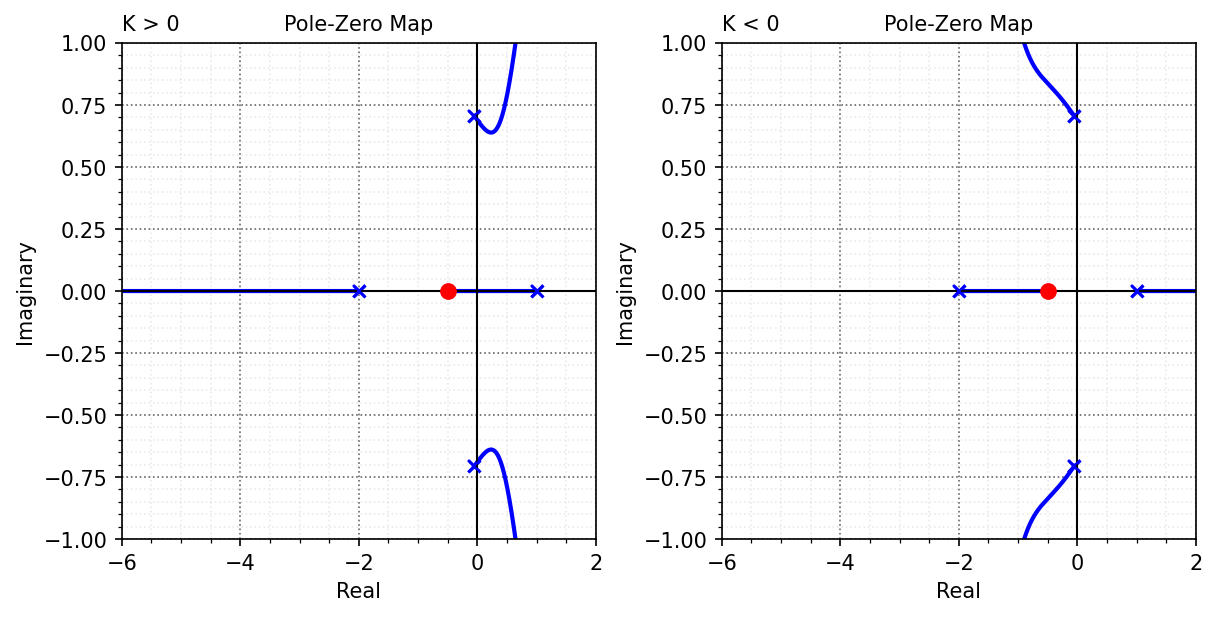

In [6]:
Gr = G*ct.tf((1), (1, .1, .5))
klist = cm.Root_Locus_gains(G)
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(Gr, gains=klist,  color='b',ax=ax[0])
ax[0].set_xlim([-6, 2]);ax[0].set_ylim([-1, 1])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

klist = cm.Root_Locus_gains(Gr)
rl = ct.rlocus(Gr, gains=[-kk for kk in klist],  color='b',ax=ax[1])
ax[1].set_xlim([-6, 2]);ax[1].set_ylim([-1, 1])
bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(Gr,ax[kk])

plt.savefig("./figs/RL_ex1_2.pdf", dpi=600)
plt.show()

## Center of Mass

For G0

Found break-in/out at K = -0.000
At possible locations s =  0.000

For G1

Found break-in/out at K =  2.726
At possible locations s = -2.266

Found break-in/out at K =  0.000
At possible locations s =  0.000


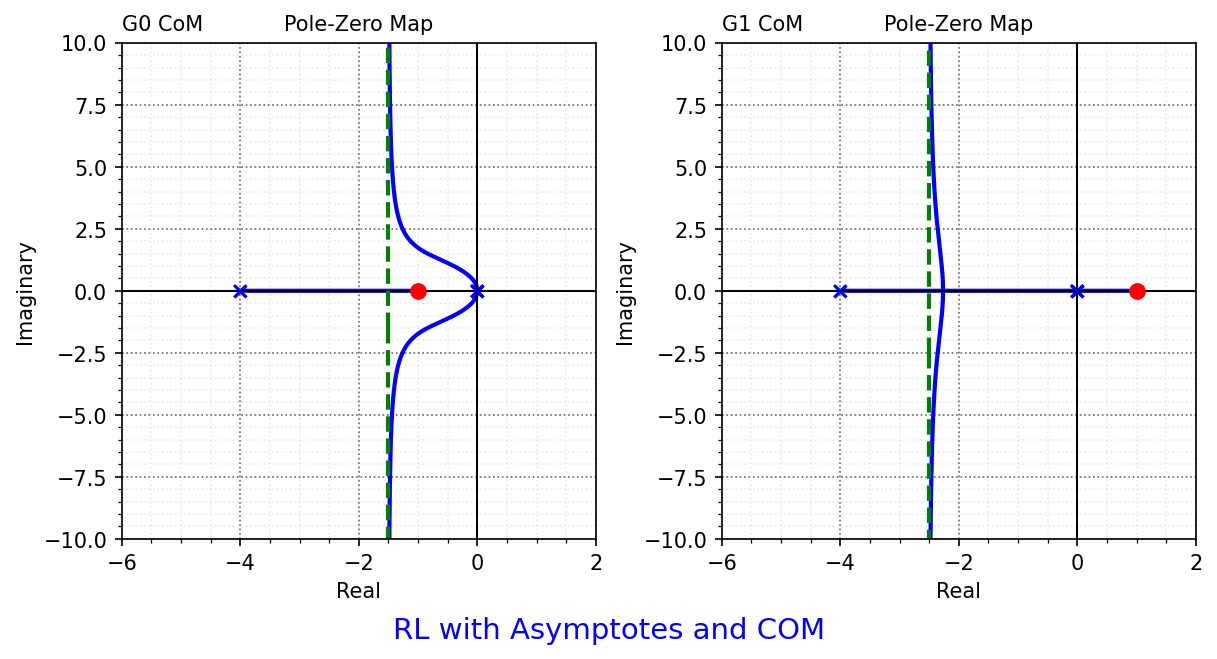

In [7]:
# 7-20

G0 = ct.tf((1, 1), np.convolve((1,0,0),(1, 4)))
G1 = ct.tf((1, -1), np.convolve((1,0,0),(1, 4)))

CoM0, Ang0 = cm.RL_COM(G0)
CoM1, Ang1 = cm.RL_COM(G1)

print("For G0")
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G0, gains=cm.Root_Locus_gains(G0),  color='b',ax=ax[0])
ax[0].set_xlim([-6, 2]);ax[0].set_ylim([-10, 10])
bm.nicegrid(ax[0])
ax[0].set_title('G0 CoM',loc='left')
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(Ang0/R2D)],'g--')
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(-Ang0/R2D)],'g--')

print("\nFor G1")
rl = ct.rlocus(G1, gains=cm.Root_Locus_gains(G1,Krange=klist),  color='b',ax=ax[1])
ax[1].set_xlim([-6, 2]);ax[1].set_ylim([-10, 10])
bm.nicegrid(ax[1])
ax[1].set_title('G1 CoM',loc='left')
ax[1].plot(np.real(CoM1)+[0,10],np.real(CoM1)+[0,10*np.tan(Ang1/R2D)],'g--')
ax[1].plot(np.real(CoM1)+[0,10],np.real(CoM1)+[0,10*np.tan(-Ang1/R2D)],'g--')
cm.caption("RL with Asymptotes and COM",fig)
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
cm.new_pzmap(G0,ax[0])
cm.new_pzmap(G1,ax[1])
fig.savefig('./figs/RL_com.pdf', dpi=300)
plt.show()

## Root Locus Examples 7-24


Found break-in/out at K = -0.000
At possible locations s =  0.000

Found break-in/out at K = -0.000
At possible locations s =  0.000

Found break-in/out at K = -0.000
At possible locations s =  0.000


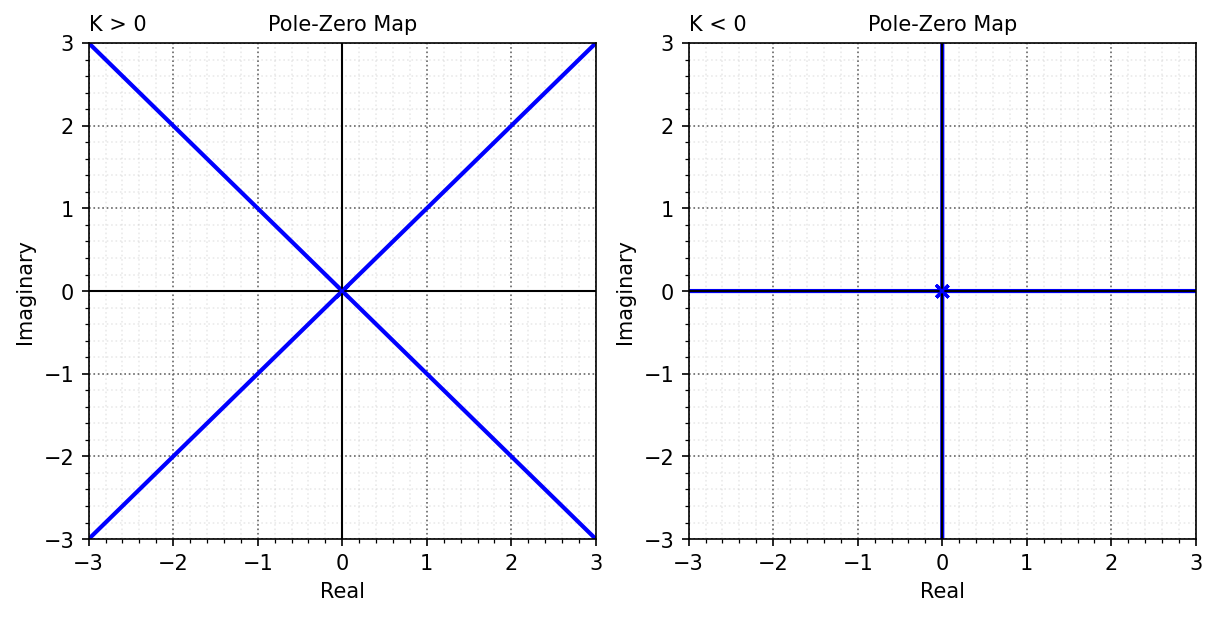

In [8]:
G = ct.tf((1), (1, 0))**4
klist = cm.Root_Locus_gains(G)
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
ax[0].set_xlim([-3, 3]);ax[0].set_ylim([-3, 3])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

rl = ct.rlocus(G, gains=[-kk for kk in klist],  color='b',ax=ax[1])
ax[1].set_xlim([-3, 3]);ax[1].set_ylim([-3, 3])
bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
cm.new_pzmap(G,ax[0])
cm.new_pzmap(G,ax[1])
plt.savefig("./figs/Ex9_21a.pdf", dpi=600)
plt.show()

K > 0

Found break-in/out at K =  2.726
At possible locations s =  2.266

Found break-in/out at K = -0.000
At possible locations s =  0.000

K < 0

Found break-in/out at K = -23.476
At possible locations s = -1.766

Found break-in/out at K = -0.000
At possible locations s =  0.000


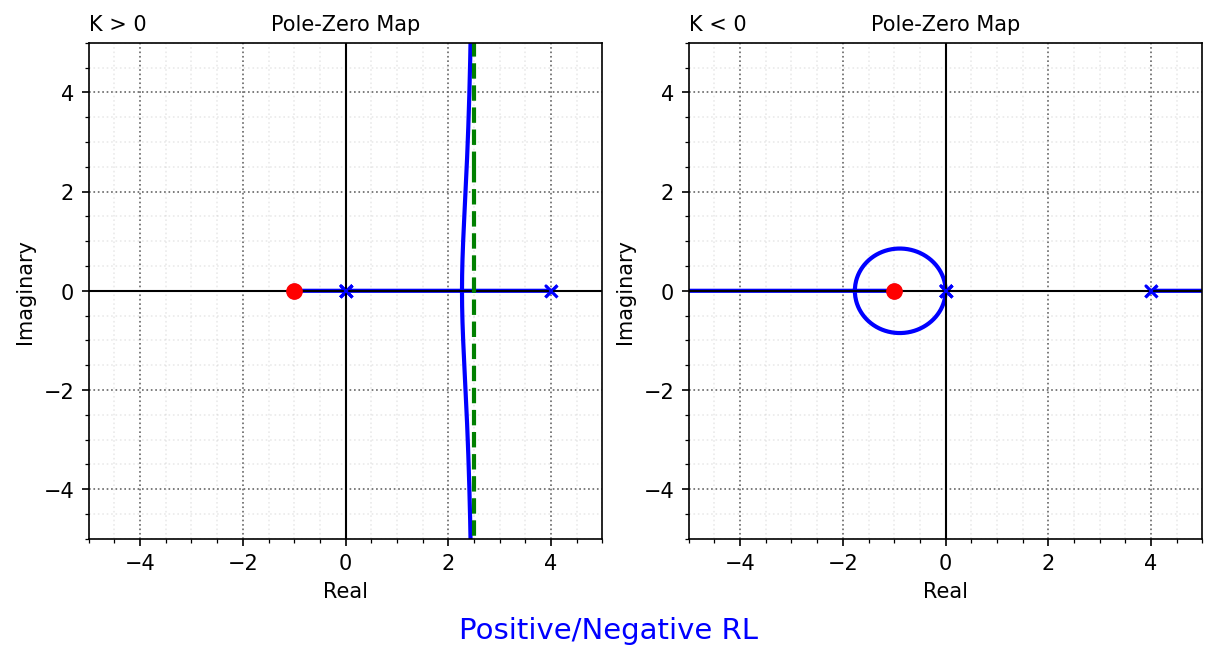

In [9]:
G = ct.tf((1, 1), np.convolve((1,0,0),(1, -4)))

print("K > 0")
klist = cm.Root_Locus_gains(G)  
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

CoM0, Ang0 = cm.RL_COM(G)
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(Ang0/R2D)],'g--')
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(-Ang0/R2D)],'g--')

print("\nK < 0")
klist = cm.Root_Locus_gains(G,standard_locus=False)  
rl = ct.rlocus(G, gains=[kk for kk in klist],  color='b',ax=ax[1])

bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
cm.caption("Positive/Negative RL",fig)
for kk in range(2):
    ax[kk].set_xlim([-5, 5]);
    ax[kk].set_ylim([-5, 5])
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G,ax[kk])

plt.savefig("./figs/Ex9_21b.pdf", dpi=600)
plt.show()


### shift LHP zero right

K > 0

Found break-in/out at K =  0.000
At possible locations s =  0.000
K < 0

Found break-in/out at K =  0.000
At possible locations s =  0.000


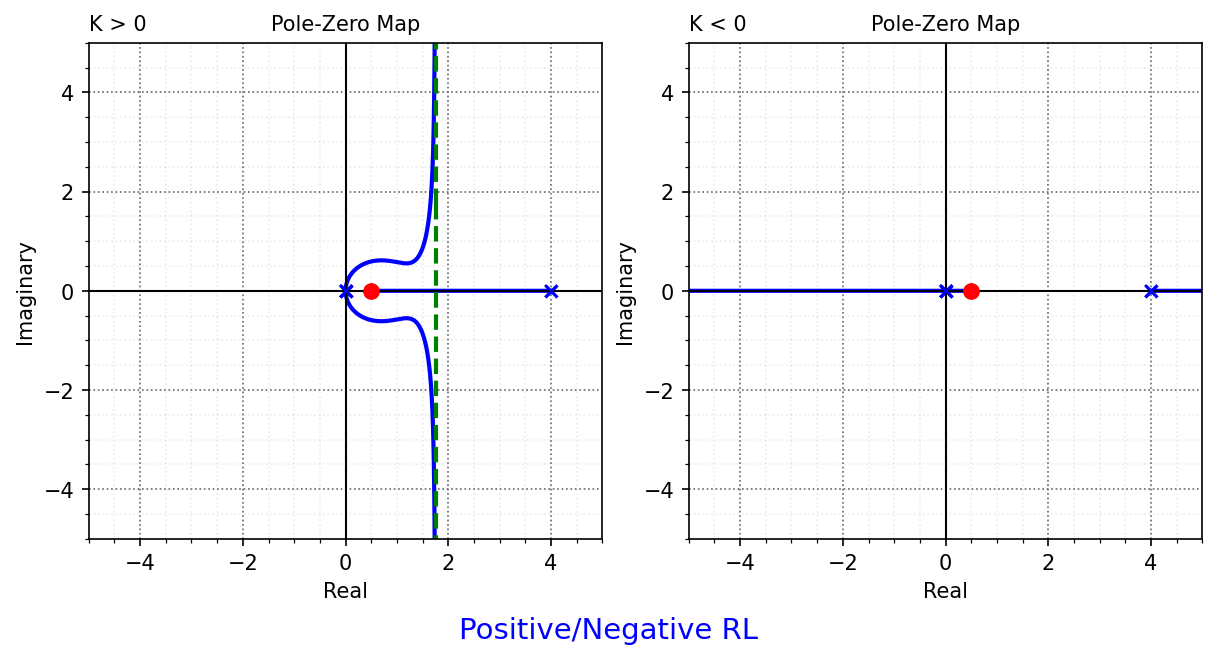

In [10]:
G = ct.tf((1, -0.5), np.convolve((1,0,0),(1, -4)))

print("K > 0")
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G),  color='b',ax=ax[0])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

CoM0, Ang0 = cm.RL_COM(G)
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(Ang0/R2D)],'g--')
ax[0].plot(np.real(CoM0)+[0,10],np.real(CoM0)+[0,10*np.tan(-Ang0/R2D)],'g--')

print("K < 0")
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G,standard_locus=False),  color='b',ax=ax[1])
bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
cm.caption("Positive/Negative RL",fig)
for kk in range(2):
    dim = 5
    ax[kk].set_xlim([-dim, dim]);
    ax[kk].set_ylim([-dim,dim])
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G,ax[kk])

plt.savefig("./figs/Ex9_21c.pdf", dpi=600)
plt.show()

## RL Examples


K > 0

Found break-in/out at K = -0.000
At possible locations s =  0.000

K < 0

Found break-in/out at K = -0.000
At possible locations s =  0.000


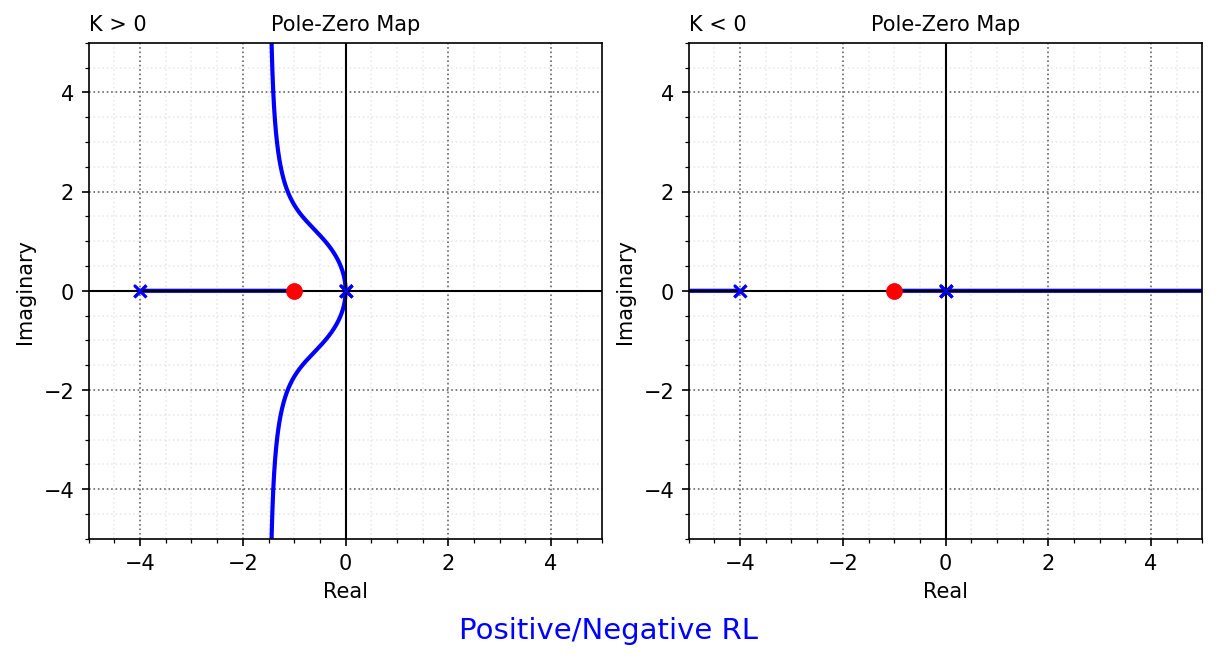

In [11]:
G = ct.tf((1, 1), np.convolve((1,0,0),(1, 4)))

print("\nK > 0")
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G,Tol = 1e-3),  color='b',ax=ax[0])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

print("\nK < 0")
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G,Tol = 1e-3,standard_locus=False),  color='b',ax=ax[1])
bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
for kk in range(2):
    ax[kk].set_xlim([-5, 5]);
    ax[kk].set_ylim([-5, 5])
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G,ax[kk])

cm.caption("Positive/Negative RL",fig)
plt.show()


K > 0

Found break-in/out at K =  3.000
At possible locations s = -2.000
K < 0

Found break-in/out at K = -1.000
At possible locations s =  0.000


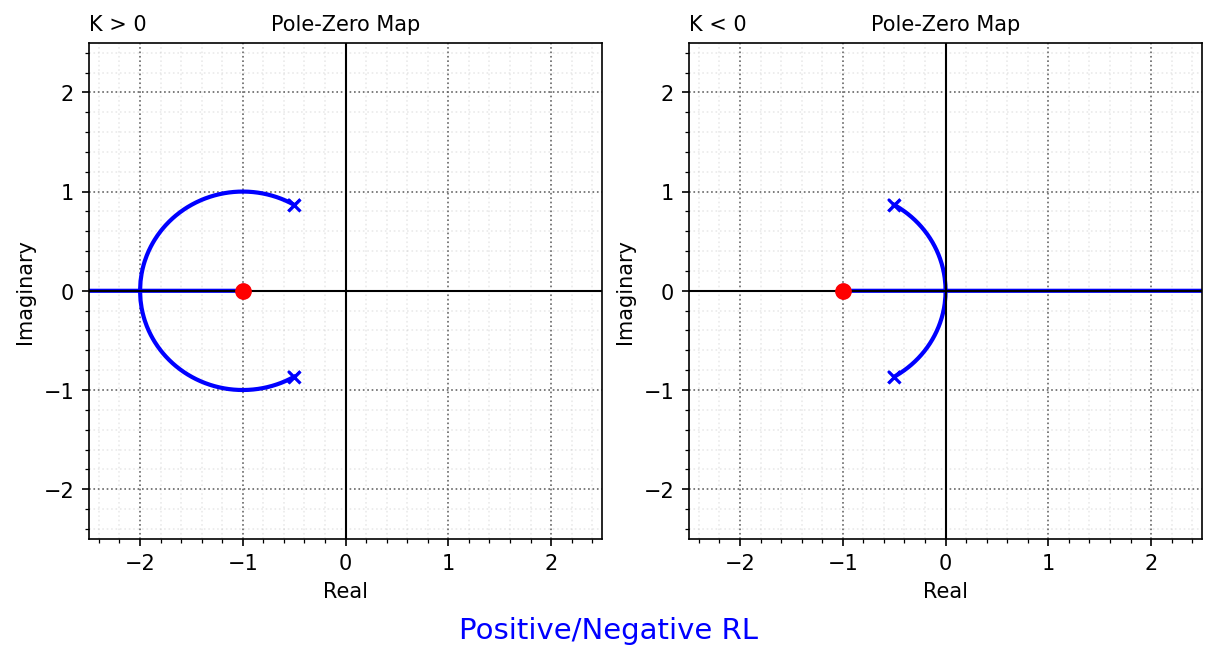

In [12]:
G = ct.tf((1, 1), np.convolve((1,1,1),(0, 1)))

print("K > 0")
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G),  color='b',ax=ax[0])
bm.nicegrid(ax[0])
ax[0].set_title('K > 0',loc='left')

print("K < 0")
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G,standard_locus=False),  color='b',ax=ax[1])
bm.nicegrid(ax[1])
ax[1].set_title('K < 0',loc='left')
for kk in range(2):
    dim = 2.5
    ax[kk].set_xlim([-dim, dim]);
    ax[kk].set_ylim([-dim, dim])
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G,ax[kk])
cm.caption("Positive/Negative RL",fig)
plt.show()


In [13]:
def quad_rl_plt(systems,ax, dim = 2, standard_locus = True):
    ''' plot root locus for four systems in a 2x2 grid '''
    for i, system in enumerate(systems):
        x, y = divmod(i, 2)
        klist, break_info = cm.Root_Locus_gains(system, standard_locus=standard_locus, verbose=True)
        rl = ct.rlocus(system, gains=klist, color='b', ax=ax[x, y])
        ax[x,y].set_xlim([-4, 1])
        ax[x,y].set_ylim([-4, 4])
        bm.nicegrid(ax[x,y])
        ax[x,y].set_xlim([-dim, dim])
        ax[x,y].set_ylim([-dim, dim])
        ax[x,y].set_xlabel('Real')
        ax[x,y].set_ylabel('Imaginary')
        cm.new_pzmap(system,ax[x,y])
        if break_info:
            k = 0
            for bp in break_info:
                poles_str = ", ".join(f"{p:5.3f}" for p in bp.poles)
                ax[x,y].text(0.1, dim-0.5 - k*0.5, f"Gain: {bp.K:5.3f} at s = {poles_str}",fontsize=8)
                k += 1

## Four examples on 7-25

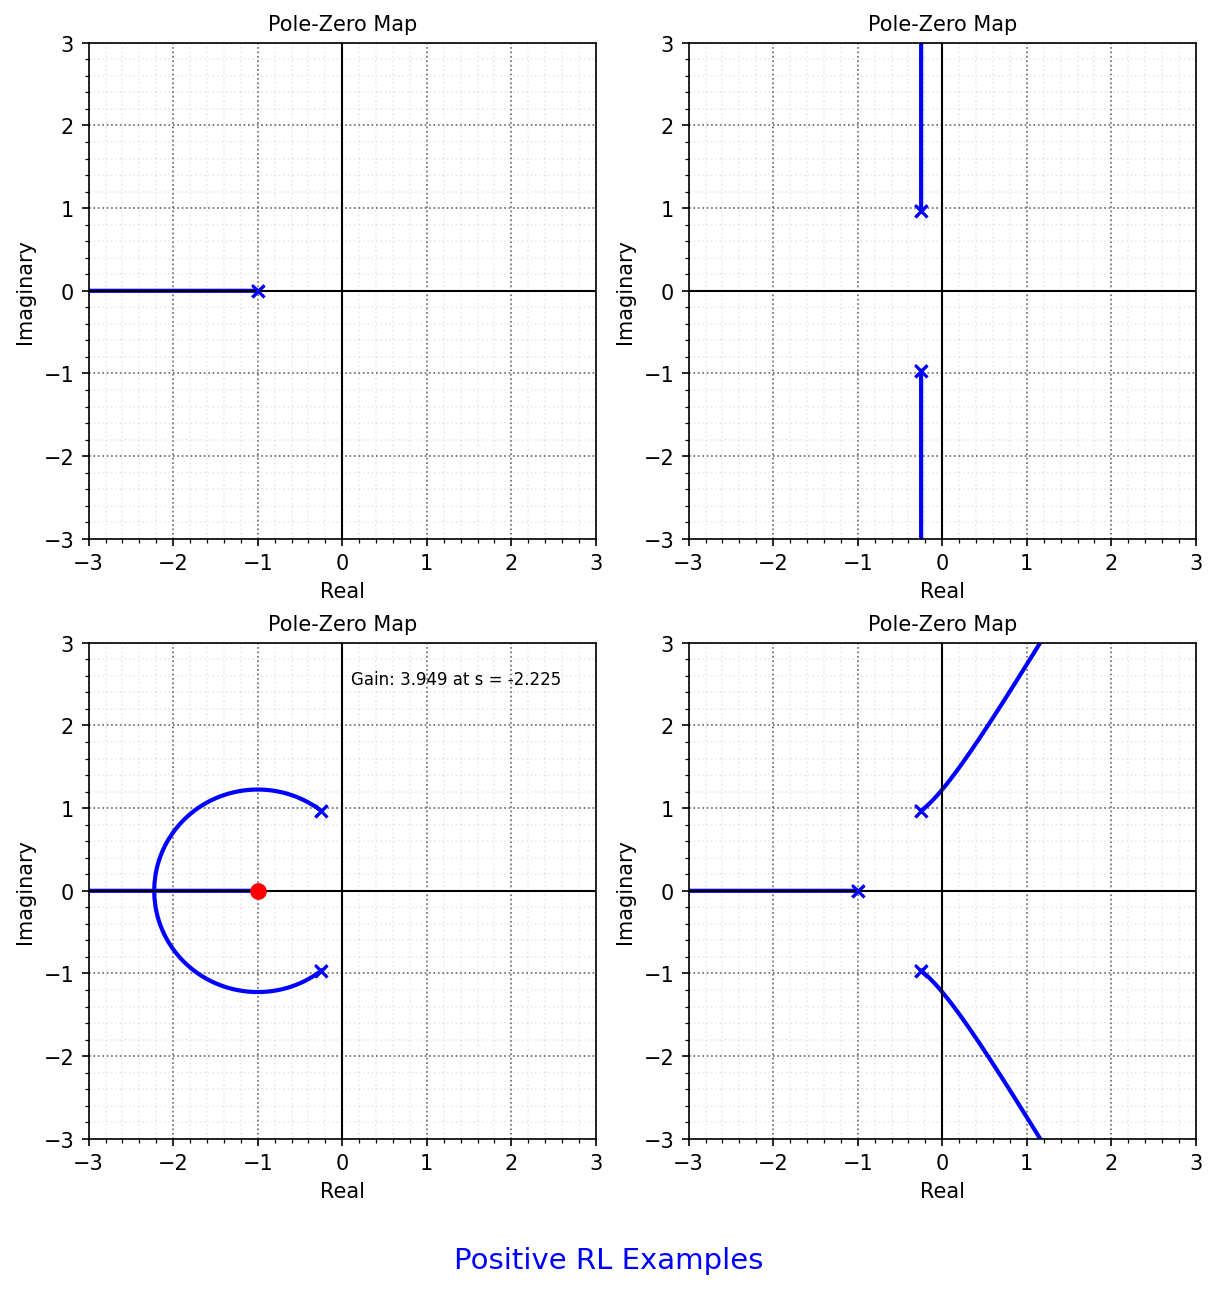

In [14]:
G0 = ct.tf((1), np.convolve((1),(1, 1)))
G1 = ct.tf((1), np.convolve((1,.5,1),(0, 1)))
G2 = ct.tf((1, 1), np.convolve((1,.5,1),(0, 1)))
G3 = ct.tf((1), np.convolve((1,.5,1),(1, 1)))

fig, ax = plt.subplots(2,2,figsize=(8, 8),dpi=150,constrained_layout = True)
systems = [G0, G1, G2, G3]
quad_rl_plt(systems,ax, dim=3, standard_locus = True)

cm.caption("Positive RL Examples",fig)
plt.savefig("./figs/Ex9_22.pdf", dpi=600)
plt.show()

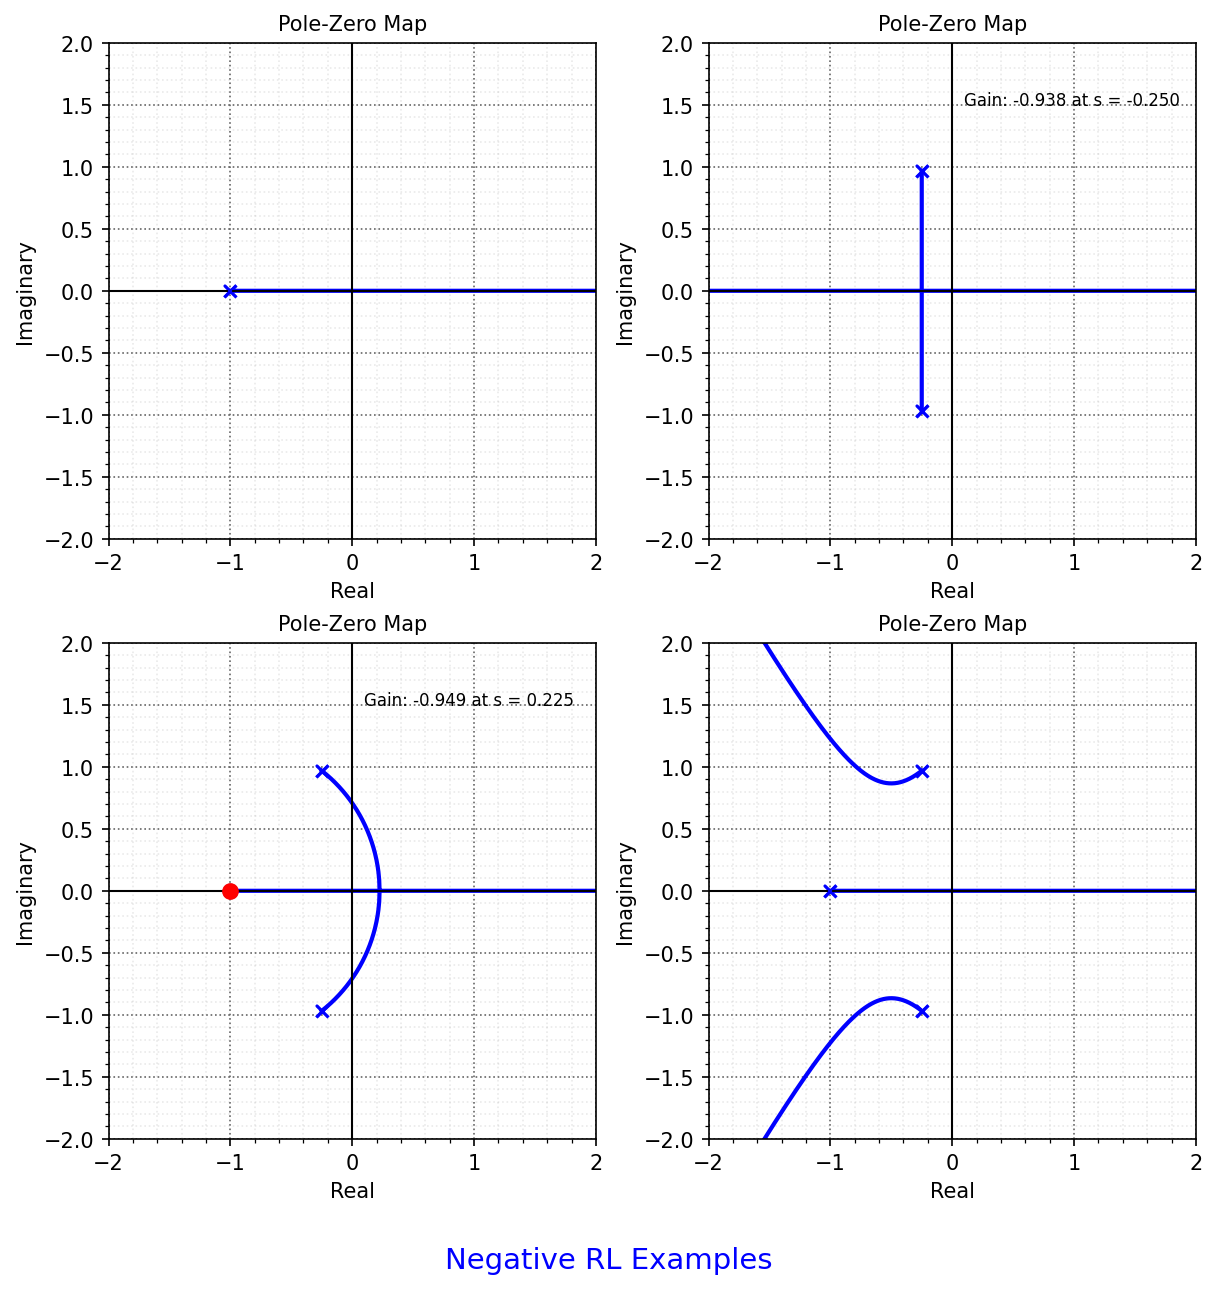

In [15]:
G0 = ct.tf((1), np.convolve((1),(1, 1)))
G1 = ct.tf((1), np.convolve((1,.5,1),(0, 1)))
G2 = ct.tf((1, 1), np.convolve((1,.5,1),(0, 1)))
G3 = ct.tf((1), np.convolve((1,.5,1),(1, 1)))

fig, ax = plt.subplots(2,2,figsize=(8, 8),dpi=150,constrained_layout = True)
systems = [G0, G1, G2, G3]
quad_rl_plt(systems,ax, standard_locus = False)
cm.caption("Negative RL Examples",fig)
plt.savefig("./figs/Ex9_22n.pdf", dpi=600)
plt.show()